# Prediksi Sentimen Saham IDX80 Berdasarkan Artikel Berita Menggunakan Metode Long Short-Term Memory

Notebook ini disusun mengikuti alur laporan skripsi pada BAB III dan BAB IV, yaitu Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, dan Deployment. Fokus penelitian adalah klasifikasi sentimen artikel berita ekonomi berbahasa Indonesia terhadap saham IDX80 menggunakan metode Long Short-Term Memory (LSTM).

Dataset utama pada versi ini adalah `idx80_3000.csv`. Label sentimen diselaraskan dengan laporan menjadi tiga kelas: `Positif`, `Netral`, dan `Negatif`. Jika dataset masih memakai label `Naik`, `Turun`, dan `Netral`, notebook akan mengubahnya menjadi `Positif`, `Negatif`, dan `Netral`. Notebook digunakan untuk training offline, sedangkan aplikasi Streamlit digunakan untuk prediksi tanpa training ulang di sisi pengguna.


## Instalasi Library

Jalankan sel berikut jika library belum tersedia di environment lokal atau Google Colab.


In [47]:
# Jalankan jika diperlukan:
!pip install pandas numpy scikit-learn tensorflow Sastrawi matplotlib



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Library


In [48]:
import json
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
except ImportError:
    StemmerFactory = None
    StopWordRemoverFactory = None


## Konfigurasi Penelitian

Konfigurasi ini disamakan dengan kebutuhan laporan dan aplikasi Streamlit. File artefak yang dihasilkan dapat langsung dipakai oleh `app.py`.


In [49]:
DATASET_PATH = Path('idx80_3000.csv')
ARTIFACT_DIR = Path('artifacts')
MODEL_PATH = ARTIFACT_DIR / 'lstm_sentiment_model.keras'
TOKENIZER_PATH = ARTIFACT_DIR / 'tokenizer.pkl'
LABEL_ENCODER_PATH = ARTIFACT_DIR / 'label_encoder.pkl'
CONFIG_PATH = ARTIFACT_DIR / 'config.json'

TITLE_COLUMN = 'judul'
BODY_COLUMN = 'isi_berita'
LABEL_COLUMN = 'sentiment'
STANDARD_LABEL_COLUMN = 'sentiment_standard'

MAX_WORDS = 10_000
MAX_LEN = 100
TEST_SIZE = 0.2
RANDOM_STATE = 42
EPOCHS = 20
BATCH_SIZE = 32
LSTM_UNITS = 128
EMBEDDING_DIM = 128

LABEL_NORMALIZATION = {
    'naik': 'Positif',
    'positif': 'Positif',
    'positive': 'Positif',
    'turun': 'Negatif',
    'negatif': 'Negatif',
    'negative': 'Negatif',
    'netral': 'Netral',
    'neutral': 'Netral',
}


# BAB III - Metodologi Penelitian

## Business Understanding

Tujuan penelitian adalah membangun sistem yang mampu mendeteksi polaritas sentimen berita ekonomi terkait emiten IDX80 secara otomatis. Sistem ini diharapkan membantu proses analisis investor karena volume berita yang besar sulit dianalisis secara manual.


## Data Understanding

Data yang digunakan berupa artikel berita ekonomi berbahasa Indonesia. Atribut utama terdiri dari `judul`, `isi_berita`, dan `sentiment`. Kolom `judul` dan `isi_berita` menjadi fitur teks, sedangkan `sentiment` menjadi target klasifikasi.


In [50]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f'Dataset tidak ditemukan: {DATASET_PATH.resolve()}. '
        'Letakkan file idx80_3000.csv di folder yang sama dengan notebook ini.'
    )

try:
    df = pd.read_csv(DATASET_PATH, encoding='utf-8-sig')
except UnicodeDecodeError:
    df = pd.read_csv(DATASET_PATH, encoding='latin1')

df.columns = [str(column).replace('\ufeff', '').strip().lower() for column in df.columns]
required_columns = {TITLE_COLUMN, BODY_COLUMN, LABEL_COLUMN}
missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(f'Kolom wajib belum ada di dataset: {sorted(missing_columns)}')

print('Total data:', len(df))
df.head()


Total data: 3000


,tanggal,judul,isi_berita,link,sentiment
0,"Tue, 30 Jun 2026 02:06:12 GMT",Breaking! IHSG Dibuka Anjlok 1% Lebih Balik ke...,Breaking! IHSG Dibuka Anjlok 1% Lebih Balik ke...,https://news.google.com/rss/articles/CBMiuAFBV...,Negatif
1,"Tue, 30 Jun 2026 03:11:15 GMT",Rekomendasi Saham Tim Analis Bareksa: SMIL & M...,Rekomendasi Saham Tim Analis Bareksa: SMIL & M...,https://news.google.com/rss/articles/CBMiugFBV...,Positif
2,"Tue, 30 Jun 2026 04:58:18 GMT","IHSG Melemah 2,87% pada Awal Perdagangan, Sima...","IHSG Melemah 2,87% pada Awal Perdagangan, Sima...",https://news.google.com/rss/articles/CBMiqAFBV...,Negatif
3,"Tue, 30 Jun 2026 03:21:56 GMT","IHSG Ambruk, 5 Saham Tersungkur hingga ARB - i...","IHSG Ambruk, 5 Saham Tersungkur hingga ARB - i...",https://news.google.com/rss/articles/CBMigAFBV...,Netral
4,"Tue, 30 Jun 2026 01:47:00 GMT",IHSG Merosot dengan Transaksi Tipis | Asing La...,IHSG Merosot dengan Transaksi Tipis | Asing La...,https://news.google.com/rss/articles/CBMitwFBV...,Negatif


In [53]:
print('Informasi dataset:')
df.info()

print('\nJumlah missing value:')
display(df[[TITLE_COLUMN, BODY_COLUMN, LABEL_COLUMN]].isna().sum())

print('\nDistribusi label asli:')
display(df[LABEL_COLUMN].value_counts())


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   tanggal     3000 non-null   object
 1   judul       3000 non-null   object
 2   isi_berita  3000 non-null   object
 3   link        3000 non-null   object
 4   sentiment   3000 non-null   object
dtypes: object(5)
memory usage: 117.3+ KB

Jumlah missing value:


judul         0
isi_berita    0
sentiment     0
dtype: int64


Distribusi label asli:


sentiment
Netral     1584
Positif     990
Negatif     426
Name: count, dtype: int64

## Data Preparation

Tahapan data preparation mengikuti laporan: case folding, cleansing, tokenizing, stopword removal, stemming, word embedding melalui Embedding Layer, dan padding. Tokenizing dan word embedding dilakukan oleh `Tokenizer` serta `Embedding` pada TensorFlow/Keras.


In [24]:
def normalize_sentiment_label(label):
    normalized = str(label).strip().lower()
    return LABEL_NORMALIZATION.get(normalized, str(label).strip().title())


if StopWordRemoverFactory is not None:
    stopword_remover = StopWordRemoverFactory().create_stop_word_remover()
else:
    stopword_remover = None
    print('Sastrawi StopWordRemover belum tersedia. Stopword removal dilewati.')

if StemmerFactory is not None:
    stemmer = StemmerFactory().create_stemmer()
else:
    stemmer = None
    print('Sastrawi Stemmer belum tersedia. Stemming dilewati.')


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    if stopword_remover is not None:
        text = stopword_remover.remove(text)

    if stemmer is not None:
        text = stemmer.stem(text)

    return text


df = df.dropna(subset=[LABEL_COLUMN]).copy()
df[STANDARD_LABEL_COLUMN] = df[LABEL_COLUMN].apply(normalize_sentiment_label)
df['text'] = df[TITLE_COLUMN].fillna('').astype(str) + ' ' + df[BODY_COLUMN].fillna('').astype(str)
df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

print('Total data setelah preprocessing:', len(df))
print('Distribusi label standar:')
display(df[STANDARD_LABEL_COLUMN].value_counts())
df[[TITLE_COLUMN, BODY_COLUMN, LABEL_COLUMN, STANDARD_LABEL_COLUMN, 'clean_text']].head()


Total data setelah preprocessing: 3000
Distribusi label standar:


sentiment_standard
Netral     1584
Positif     990
Negatif     426
Name: count, dtype: int64

,judul,isi_berita,sentiment,sentiment_standard,clean_text
0,Breaking! IHSG Dibuka Anjlok 1% Lebih Balik ke...,Breaking! IHSG Dibuka Anjlok 1% Lebih Balik ke...,Negatif,Negatif,breaking ihsg buka anjlok lebih balik level cn...
1,Rekomendasi Saham Tim Analis Bareksa: SMIL & M...,Rekomendasi Saham Tim Analis Bareksa: SMIL & M...,Positif,Positif,rekomendasi saham tim analis bareksa smil mtel...
2,"IHSG Melemah 2,87% pada Awal Perdagangan, Sima...","IHSG Melemah 2,87% pada Awal Perdagangan, Sima...",Negatif,Negatif,ihsg lemah awal dagang simak gera saham hari a...
3,"IHSG Ambruk, 5 Saham Tersungkur hingga ARB - i...","IHSG Ambruk, 5 Saham Tersungkur hingga ARB - i...",Netral,Netral,ihsg ambruk saham sungkur hingga arb investor ...
4,IHSG Merosot dengan Transaksi Tipis | Asing La...,IHSG Merosot dengan Transaksi Tipis | Asing La...,Negatif,Negatif,ihsg merosot transaksi tipis asing lanjut sell...


In [25]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df[STANDARD_LABEL_COLUMN].astype(str))

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print('Mapping label:', label_mapping)


Mapping label: {'Negatif': np.int64(0), 'Netral': np.int64(1), 'Positif': np.int64(2)}


In [26]:
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN)
y = df['label'].values

print('Shape X:', X.shape)
print('Shape y:', y.shape)
print('Jumlah kata unik:', len(tokenizer.word_index))


Shape X: (3000, 100)
Shape y: (3000,)
Jumlah kata unik: 3110


In [27]:
class_counts = pd.Series(y).value_counts()
stratify_target = y if class_counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_target,
)

print('Data train:', X_train.shape[0])
print('Data test:', X_test.shape[0])


Data train: 2400
Data test: 600


## Modeling

Model utama menggunakan arsitektur Long Short-Term Memory (LSTM). LSTM dipilih karena mampu memproses data berurutan dan mempertahankan konteks informasi jangka panjang pada teks berita. Arsitektur model terdiri dari Input Layer, Embedding Layer, LSTM 128 unit, Dropout, Dense Layer, dan output Softmax untuk klasifikasi multi-kelas.


In [28]:
num_classes = len(label_encoder.classes_)

model = Sequential(
    [
        Input(shape=(MAX_LEN,)),
        Embedding(MAX_WORDS, EMBEDDING_DIM),
        LSTM(LSTM_UNITS),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax'),
    ]
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,415,811 (5.40 MB)

 Trainable params: 1,415,811 (5.40 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1,
)


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9965 - loss: 0.0152 - val_accuracy: 0.9300 - val_loss: 0.3210
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9929 - loss: 0.0333 - val_accuracy: 0.9317 - val_loss: 0.4386
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9977 - loss: 0.0080 - val_accuracy: 0.9367 - val_loss: 0.3753
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9972 - loss: 0.0105 - val_accuracy: 0.9333 - val_loss: 0.2865
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9940 - loss: 0.0195 - val_accuracy: 0.9283 - val_loss: 0.3254
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9985 - loss: 0.0066 - val_accuracy: 0.9250 - val_loss: 0.3476
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9940 - loss: 0.0169 - val_accuracy: 0.9350 - val_loss: 0.3116


## Evaluation

Evaluasi model menggunakan metrik Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix sebagaimana dijelaskan pada laporan.


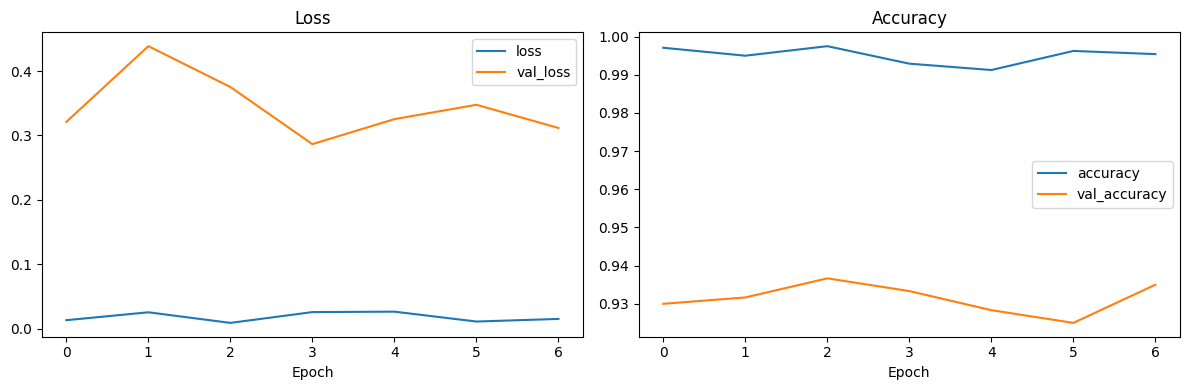

In [41]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[['loss', 'val_loss']].plot(ax=axes[0], title='Loss')
history_df[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Accuracy')

axes[0].set_xlabel('Epoch')
axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.show()


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Akurasi data test: 0.9333

Classification report:


,precision,recall,f1-score,support
Negatif,0.873563,0.894118,0.883721,85.000000
Netral,0.937304,0.943218,0.940252,317.000000
Positif,0.953608,0.934343,0.943878,198.000000
accuracy,0.933333,0.933333,0.933333,0.933333
macro avg,0.921492,0.923893,0.922617,600.000000
weighted avg,0.933654,0.933333,0.933440,600.000000


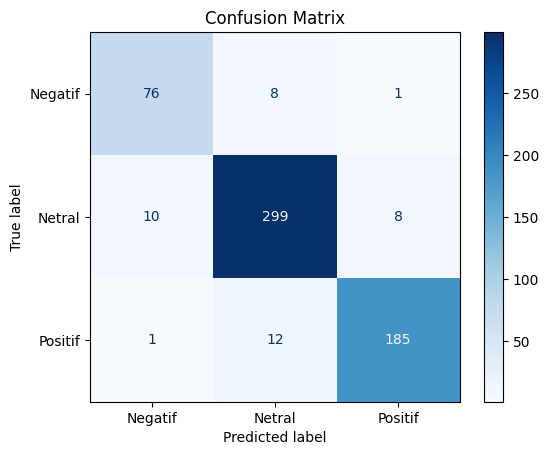

In [42]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

accuracy = accuracy_score(y_test, y_pred)
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).transpose()

print(f'Akurasi data test: {accuracy:.4f}')
print('\nClassification report:')
display(report_df)

cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
cm_display.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()


## Deployment

Tahap deployment dilakukan dengan menyimpan model dan artefak pendukung agar dapat digunakan pada aplikasi Streamlit. Pada versi terbaru, aplikasi tidak menampilkan halaman Training agar pengguna tidak perlu melatih ulang model saat melakukan prediksi. Proses training dilakukan secara offline melalui notebook ini, sedangkan aplikasi Streamlit berfokus pada halaman Prediksi dan Informasi Model. Halaman Prediksi memuat dua mode, yaitu Artikel Tunggal dan Batch CSV.


In [43]:
ARTIFACT_DIR.mkdir(exist_ok=True)
model.save(MODEL_PATH)

with TOKENIZER_PATH.open('wb') as file:
    pickle.dump(tokenizer, file)

with LABEL_ENCODER_PATH.open('wb') as file:
    pickle.dump(label_encoder, file)

config = {
    'max_words': MAX_WORDS,
    'max_len': MAX_LEN,
    'classes': label_encoder.classes_.tolist(),
    'title_column': TITLE_COLUMN,
    'body_column': BODY_COLUMN,
    'label_column': LABEL_COLUMN,
    'standard_label_column': STANDARD_LABEL_COLUMN,
    'training_rows': int(len(df)),
    'test_accuracy': float(accuracy),
    'lstm_units': LSTM_UNITS,
    'embedding_dim': EMBEDDING_DIM,
    'preprocessing': ['case_folding', 'cleansing', 'stopword_removal', 'stemming', 'tokenizing', 'padding'],
}

CONFIG_PATH.write_text(json.dumps(config, indent=2), encoding='utf-8')

print('Model tersimpan di:', MODEL_PATH)
print('Tokenizer tersimpan di:', TOKENIZER_PATH)
print('Label encoder tersimpan di:', LABEL_ENCODER_PATH)
print('Config tersimpan di:', CONFIG_PATH)


Model tersimpan di: artifacts\lstm_sentiment_model.keras
Tokenizer tersimpan di: artifacts\tokenizer.pkl
Label encoder tersimpan di: artifacts\label_encoder.pkl
Config tersimpan di: artifacts\config.json


# BAB IV - Hasil dan Pembahasan

## Contoh Prediksi Sentimen

Sel berikut menunjukkan contoh penggunaan model untuk memprediksi sentimen artikel baru. Hasil prediksi terdiri dari label sentimen, confidence, dan distribusi probabilitas setiap kelas. Pada aplikasi Streamlit, fitur ini ditempatkan pada halaman `Prediksi` mode `Artikel Tunggal`.


In [44]:
def predict_sentiment(text):
    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded_sequence = pad_sequences(sequence, maxlen=MAX_LEN)
    probabilities = model.predict(padded_sequence, verbose=0)[0]
    class_index = int(np.argmax(probabilities))
    predicted_label = label_encoder.inverse_transform([class_index])[0]

    probability_table = pd.DataFrame(
        {
            'sentiment': label_encoder.classes_,
            'probability': probabilities,
        }
    ).sort_values('probability', ascending=False)

    return predicted_label, float(probabilities[class_index]), cleaned_text, probability_table


In [45]:
contoh_berita = 'BCA targetkan pertumbuhan penyaluran KPR 6 persen sampai 7 persen pada tahun 2026.'

predicted_label, confidence, cleaned_text, probability_table = predict_sentiment(contoh_berita)

print('Teks bersih:', cleaned_text)
print('Prediksi sentimen:', predicted_label)
print(f'Confidence: {confidence:.2%}')
display(probability_table)


Teks bersih: bca target tumbuh salur kpr persen persen tahun
Prediksi sentimen: Positif
Confidence: 99.09%


,sentiment,probability
2,Positif,0.990911
1,Netral,0.004544
0,Negatif,0.004544


## Load Ulang Model untuk Inferensi

Sel ini opsional. Tujuannya memastikan model yang telah disimpan dapat dimuat ulang dan digunakan pada aplikasi Streamlit tanpa training ulang di sisi pengguna.


In [46]:
loaded_model = load_model(MODEL_PATH)

with TOKENIZER_PATH.open('rb') as file:
    loaded_tokenizer = pickle.load(file)

with LABEL_ENCODER_PATH.open('rb') as file:
    loaded_label_encoder = pickle.load(file)

loaded_config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
print('Model berhasil dimuat ulang.')
print(loaded_config)


Model berhasil dimuat ulang.
{'max_words': 10000, 'max_len': 100, 'classes': ['Negatif', 'Netral', 'Positif'], 'title_column': 'judul', 'body_column': 'isi_berita', 'label_column': 'sentiment', 'standard_label_column': 'sentiment_standard', 'training_rows': 3000, 'test_accuracy': 0.9333333333333333, 'lstm_units': 128, 'embedding_dim': 128, 'preprocessing': ['case_folding', 'cleansing', 'stopword_removal', 'stemming', 'tokenizing', 'padding']}
